# Model 1: MS-UNet (Multi-Scale U-Net) — Fetal Head Segmentation
**Dataset:** HC18 Grand Challenge — https://zenodo.org/records/1322001

**Architecture:** U-Net with multi-scale feature extraction using dilated convolutions at different rates in the encoder blocks, enabling the model to capture features at multiple receptive field sizes simultaneously.

**Goal:** Segment fetal head from ultrasound images and estimate head circumference (HC).

## 1. Install Dependencies

In [ ]:
!pip install segmentation-models-pytorch timm albumentations opencv-python matplotlib pandas tqdm grad-cam -q

## 2. Download HC18 Dataset

In [ ]:
import os

# --- Download from Zenodo ---
# HC18 Grand Challenge dataset
# Training set: 999 images + annotations
# Test set: 335 images (no public annotations — we split training for val)

!wget -q --show-progress 'https://zenodo.org/records/1322001/files/training_set.zip' -O training_set.zip
!wget -q --show-progress 'https://zenodo.org/records/1322001/files/test_set.zip' -O test_set.zip
!unzip -q training_set.zip -d hc18
!unzip -q test_set.zip -d hc18
print('Dataset ready.')

## 3. Imports & Config

In [1]:
import os, random, math, time, warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from glob import glob
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ── Config ────────────────────────────────────────────────────────────────────
IMG_SIZE   = 256
BATCH_SIZE = 8
EPOCHS     = 100
LR         = 1e-4
PATIENCE   = 15          # early stopping
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_NAME = 'ms_unet'

TRAIN_IMG_DIR  = 'hc18/training_set'
TEST_IMG_DIR   = 'hc18/test_set'

print(f'Device : {DEVICE}')
print(f'Model  : MS-UNet (Multi-Scale)')

c:\Users\shyle\OneDrive\Documents\Projects\Fetal_Head_Circumference\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
Model  : MS-UNet (Multi-Scale)


## 4. Dataset & Augmentation

In [2]:
def get_file_pairs(img_dir):
    """Return sorted list of (image_path, mask_path) tuples."""
    imgs  = sorted(glob(os.path.join(img_dir, '*_HC.png')))
    masks = [p.replace('_HC.png', '_HC_Annotation.png') for p in imgs]
    pairs = [(i, m) for i, m in zip(imgs, masks) if os.path.exists(m)]
    return pairs


def patient_split(pairs, val_ratio=0.15, test_ratio=0.10, seed=SEED):
    """Patient-level split to prevent data leakage."""
    rng = random.Random(seed)
    all_pairs = pairs.copy()
    rng.shuffle(all_pairs)
    n = len(all_pairs)
    n_val  = int(n * val_ratio)
    n_test = int(n * test_ratio)
    test   = all_pairs[:n_test]
    val    = all_pairs[n_test:n_test + n_val]
    train  = all_pairs[n_test + n_val:]
    return train, val, test


def get_transforms(split='train'):
    if split == 'train':
        return A.Compose([
            A.PadIfNeeded(IMG_SIZE, IMG_SIZE, border_mode=cv2.BORDER_CONSTANT),
            A.RandomCrop(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.GaussNoise(p=0.3),
            A.RandomBrightnessContrast(p=0.3),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])
    else:
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])


class HC18Dataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.pairs     = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, msk_path = self.pairs[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        msk = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)
        msk = (msk > 127).astype(np.float32)

        if self.transform:
            aug = self.transform(image=img, mask=msk)
            img, msk = aug['image'], aug['mask']

        return img, msk.unsqueeze(0)
        


# ── Build splits ─────────────────────────────────────────────────────────────
all_pairs = get_file_pairs(TRAIN_IMG_DIR)
train_pairs, val_pairs, test_pairs = patient_split(all_pairs)

print(f'Train : {len(train_pairs)} | Val : {len(val_pairs)} | Test : {len(test_pairs)}')

train_ds = HC18Dataset(train_pairs, get_transforms('train'))
val_ds   = HC18Dataset(val_pairs,   get_transforms('val'))
test_ds  = HC18Dataset(test_pairs,  get_transforms('val'))

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

Train : 586 | Val : 116 | Test : 77


## 5. MS-UNet Architecture

Multi-Scale UNet replaces standard 3×3 convolutions in each encoder block with a **parallel multi-scale module** that runs 3 branches simultaneously:
- Branch 1: standard 3×3 conv (rate=1)
- Branch 2: dilated conv (rate=2) for 2× receptive field
- Branch 3: dilated conv (rate=4) for 4× receptive field

All branches are concatenated and projected back to the same channel count. This allows each layer to "see" context at multiple scales without increasing depth.

In [3]:
class MultiScaleConvBlock(nn.Module):
    """Three parallel dilated convolutions + channel fusion."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        mid = out_ch // 3 + 1          # each branch produces ~1/3 of out_ch

        self.b1 = self._conv(in_ch, mid, dilation=1)
        self.b2 = self._conv(in_ch, mid, dilation=2)
        self.b3 = self._conv(in_ch, mid, dilation=4)
        self.fuse = nn.Sequential(
            nn.Conv2d(mid * 3, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    @staticmethod
    def _conv(in_ch, out_ch, dilation):
        pad = dilation
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=pad, dilation=dilation, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.fuse(torch.cat([self.b1(x), self.b2(x), self.b3(x)], dim=1))


class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.ms1  = MultiScaleConvBlock(in_ch, out_ch)
        self.ms2  = MultiScaleConvBlock(out_ch, out_ch)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        skip = self.ms2(self.ms1(x))
        return self.pool(skip), skip


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = nn.Sequential(
            MultiScaleConvBlock(out_ch + skip_ch, out_ch),
            MultiScaleConvBlock(out_ch, out_ch)
        )

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class MSUNet(nn.Module):
    """Multi-Scale U-Net for binary segmentation."""
    def __init__(self, in_ch=3, out_ch=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.encoders = nn.ModuleList()
        prev = in_ch
        for f in features:
            self.encoders.append(EncoderBlock(prev, f))
            prev = f

        self.bottleneck = nn.Sequential(
            MultiScaleConvBlock(features[-1], features[-1] * 2),
            MultiScaleConvBlock(features[-1] * 2, features[-1] * 2)
        )

        self.decoders = nn.ModuleList()
        rev = list(reversed(features))
        in_d = features[-1] * 2
        for f in rev:
            self.decoders.append(DecoderBlock(in_d, f, f))
            in_d = f

        self.head = nn.Conv2d(features[0], out_ch, 1)

    def forward(self, x):
        skips = []
        for enc in self.encoders:
            x, skip = enc(x)
            skips.append(skip)

        x = self.bottleneck(x)

        for dec, skip in zip(self.decoders, reversed(skips)):
            x = dec(x, skip)

        return torch.sigmoid(self.head(x))


model = MSUNet().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'MS-UNet parameters: {total_params:,}')

MS-UNet parameters: 34,627,439


## 6. Loss, Metrics & Optimizer

In [4]:
# ── Hybrid Dice + BCE loss (matches the base paper) ───────────────────────────
def hybrid_loss(pred, target, smooth=1e-6):
    bce  = F.binary_cross_entropy(pred, target)
    inter = (pred * target).sum(dim=(2, 3))
    dice_loss = 1 - (2 * inter + smooth) / (pred.sum(dim=(2,3)) + target.sum(dim=(2,3)) + smooth)
    return bce + dice_loss.mean()


def compute_metrics(pred, target, thresh=0.5, smooth=1e-6):
    pred_b = (pred > thresh).float()
    tp = (pred_b * target).sum()
    fp = (pred_b * (1 - target)).sum()
    fn = ((1 - pred_b) * target).sum()
    tn = ((1 - pred_b) * (1 - target)).sum()

    dice      = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
    iou       = (tp + smooth) / (tp + fp + fn + smooth)
    precision = (tp + smooth) / (tp + fp + smooth)
    recall    = (tp + smooth) / (tp + fn + smooth)
    f1        = dice
    accuracy  = (tp + tn + smooth) / (tp + tn + fp + fn + smooth)
    specificity = (tn + smooth) / (tn + fp + smooth)

    return {
        'dice': dice.item(), 'iou': iou.item(),
        'precision': precision.item(), 'recall': recall.item(),
        'f1': f1.item(), 'accuracy': accuracy.item(),
        'specificity': specificity.item()
    }


optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

print('Loss   : Hybrid Dice + BCE')
print('Optim  : Adam lr=1e-4')
print('Sched  : ReduceLROnPlateau')

Loss   : Hybrid Dice + BCE
Optim  : Adam lr=1e-4
Sched  : ReduceLROnPlateau


## 7. Training Loop

In [5]:
history = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': []}
best_val_loss = float('inf')
patience_ctr  = 0


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0
    all_metrics = {k: 0.0 for k in ['dice','iou','precision','recall','f1','accuracy','specificity']}

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, masks in tqdm(loader, leave=False):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = model(imgs)
            loss  = hybrid_loss(preds, masks)

            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()

            total_loss += loss.item()
            m = compute_metrics(preds.detach(), masks)
            for k in all_metrics: all_metrics[k] += m[k]

    n = len(loader)
    return total_loss / n, {k: v / n for k, v in all_metrics.items()}


print(f'Training MS-UNet for up to {EPOCHS} epochs on {DEVICE}...\n')
start = time.time()

for epoch in range(1, EPOCHS + 1):
    t_loss, _      = run_epoch(train_dl, train=True)
    v_loss, v_mets = run_epoch(val_dl,   train=False)
    scheduler.step(v_loss)

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['val_dice'].append(v_mets['dice'])
    history['val_iou'].append(v_mets['iou'])

    if epoch % 10 == 0 or epoch == 1:
        print(f'Ep {epoch:03d}/{EPOCHS} | '
              f'Train Loss: {t_loss:.4f} | '
              f'Val Loss: {v_loss:.4f} | '
              f'Dice: {v_mets["dice"]:.4f} | '
              f'IoU: {v_mets["iou"]:.4f}')

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save(model.state_dict(), f'best_{MODEL_NAME}.pth')
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

print(f'\nTraining complete in {(time.time()-start)/60:.1f} min')
print(f'Best val loss: {best_val_loss:.4f}')

Training MS-UNet for up to 100 epochs on cuda...



Ep 001/100 | Train Loss: 1.4930 | Val Loss: 1.3883 | Dice: 0.0000 | IoU: 0.0000


Ep 010/100 | Train Loss: 1.1030 | Val Loss: 1.1072 | Dice: 0.0000 | IoU: 0.0000


Ep 020/100 | Train Loss: 1.0019 | Val Loss: 1.0346 | Dice: 0.1002 | IoU: 0.0528


Ep 030/100 | Train Loss: 0.9453 | Val Loss: 1.0016 | Dice: 0.1133 | IoU: 0.0602


Ep 040/100 | Train Loss: 0.9058 | Val Loss: 0.9877 | Dice: 0.1059 | IoU: 0.0560


Ep 050/100 | Train Loss: 0.8890 | Val Loss: 0.9854 | Dice: 0.1076 | IoU: 0.0570


Ep 060/100 | Train Loss: 0.8903 | Val Loss: 0.9832 | Dice: 0.1145 | IoU: 0.0609


Early stopping at epoch 67

Training complete in 59.3 min
Best val loss: 0.9775


## 8. Training Curves

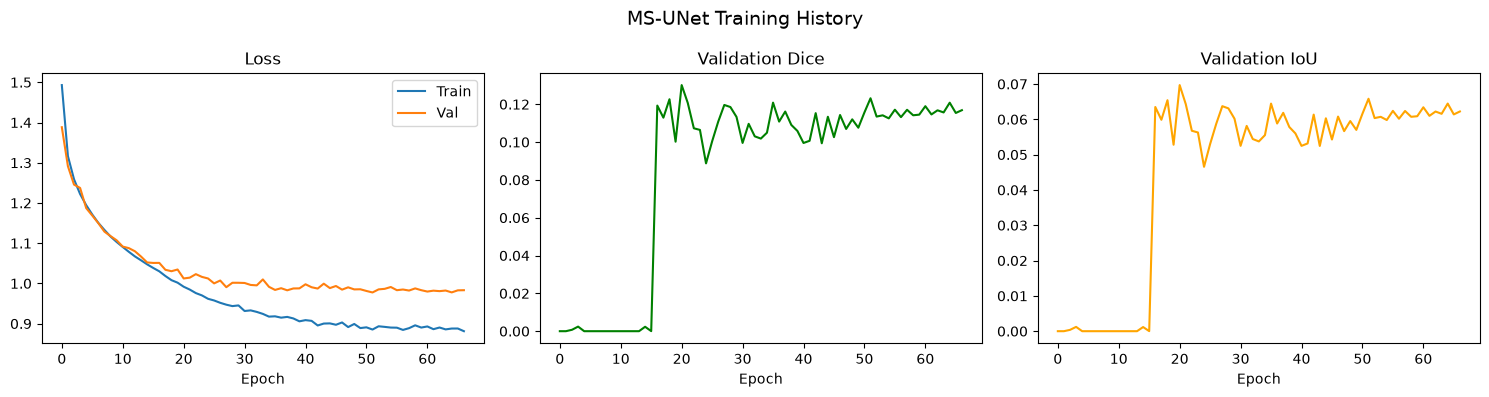

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('MS-UNet Training History', fontsize=14)

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(history['val_dice'], color='green')
axes[1].set_title('Validation Dice'); axes[1].set_xlabel('Epoch')

axes[2].plot(history['val_iou'], color='orange')
axes[2].set_title('Validation IoU'); axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(f'{MODEL_NAME}_training_curves.png', dpi=150)
plt.show()

## 9. Test Evaluation

In [7]:
# Load best checkpoint
model.load_state_dict(torch.load(f'best_{MODEL_NAME}.pth', map_location=DEVICE))
model.eval()

test_loss, test_mets = run_epoch(test_dl, train=False)

print('=' * 50)
print(f'  MS-UNet — Test Results')
print('=' * 50)
for k, v in test_mets.items():
    print(f'  {k:<12}: {v*100:.2f}%')
print(f'  {"loss":<12}: {test_loss:.4f}')
print('=' * 50)

  MS-UNet — Test Results
  dice        : 12.97%
  iou         : 6.95%
  precision   : 7.69%
  recall      : 41.96%
  f1          : 12.97%
  accuracy    : 95.82%
  specificity : 96.22%
  loss        : 0.9698


## 10. Head Circumference (HC) Estimation

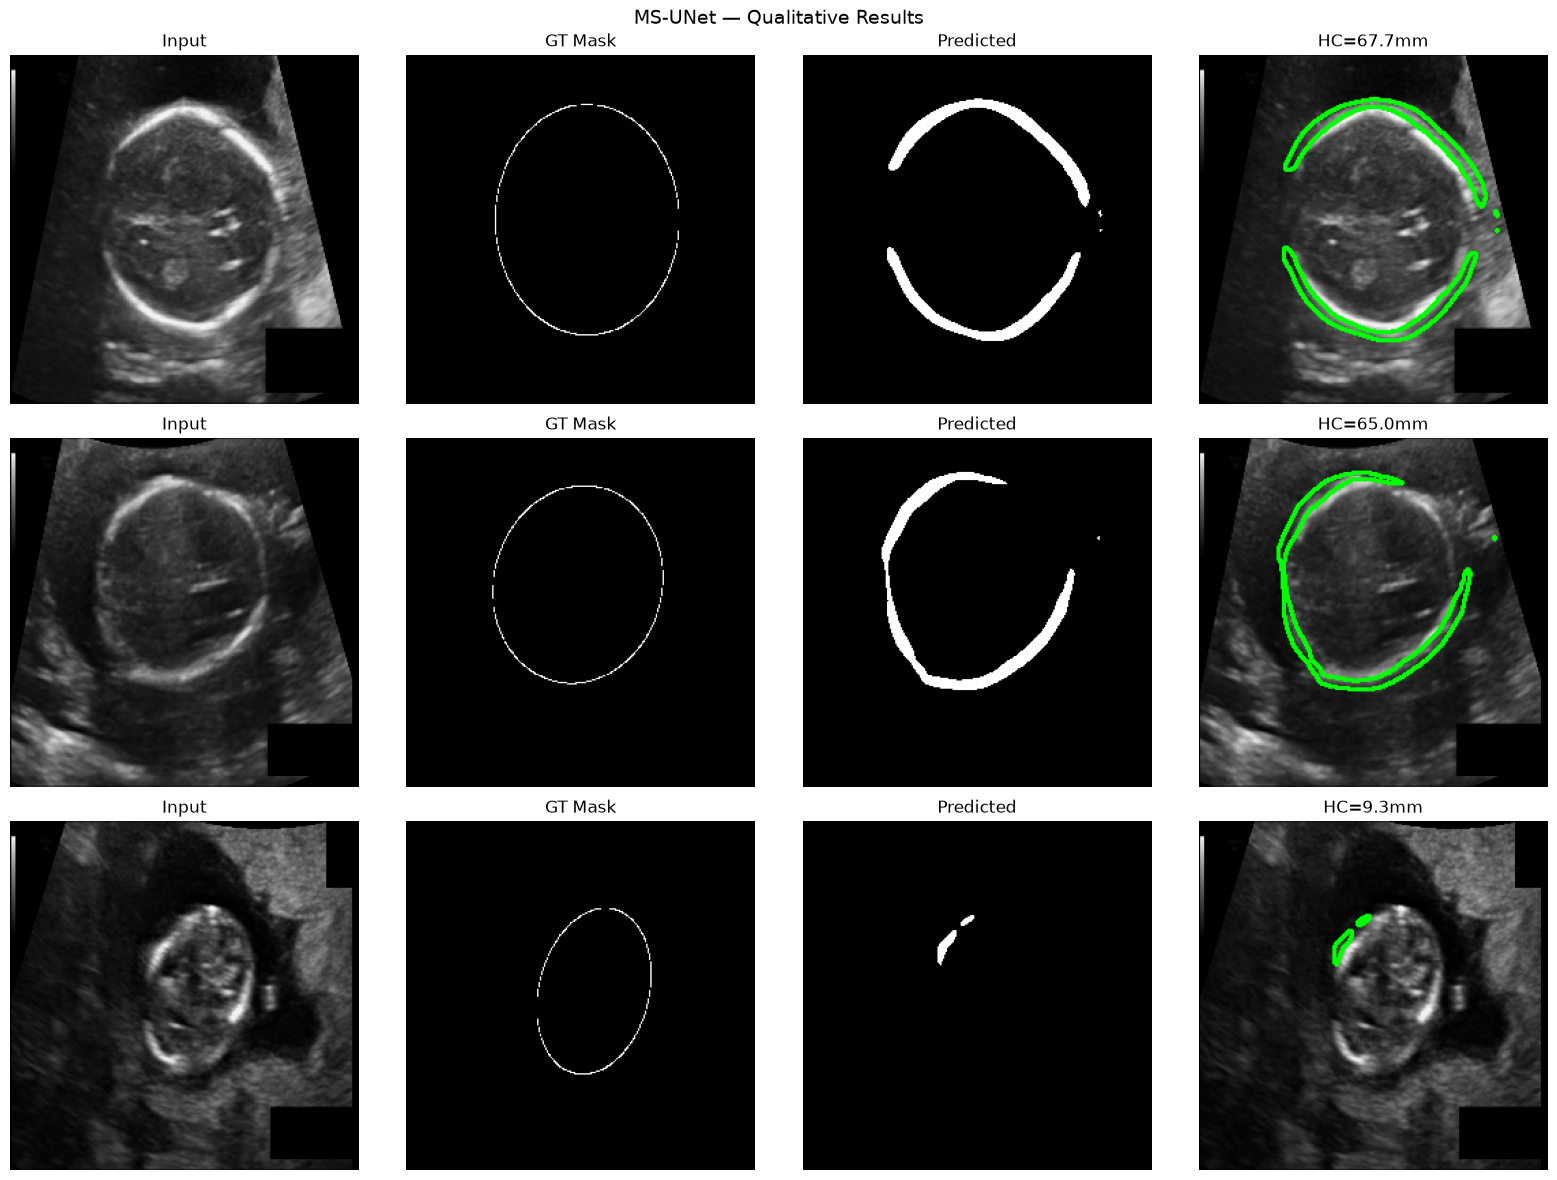

HC MAE : 28.38 mm
HC MSE : 1125.29 mm²


In [8]:
def estimate_hc(mask_np, pixel_size_mm=0.143):
    """Fit ellipse to largest contour and compute HC using Ramanujan's formula."""
    mask_u8 = (mask_np * 255).astype(np.uint8)
    kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask_u8 = cv2.morphologyEx(mask_u8, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours: return None, None

    largest = max(contours, key=cv2.contourArea)
    if len(largest) < 5: return None, None

    (cx, cy), (MA, ma), angle = cv2.fitEllipse(largest)
    a, b = MA / 2, ma / 2          # semi-axes in pixels
    h    = ((a - b) ** 2) / ((a + b) ** 2)
    hc_px = math.pi * (3*(a+b) - math.sqrt((3*a+b)*(a+3*b)))
    hc_mm = hc_px * pixel_size_mm
    return hc_mm, (cx, cy, a, b, angle)


# ── Quick HC estimation on a few test samples ─────────────────────────────────
denorm_mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
denorm_std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

model.eval()
hc_errors = []
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

with torch.no_grad():
    for idx, (imgs, masks) in enumerate(test_dl):
        if idx >= 1: break
        preds = model(imgs.to(DEVICE)).cpu()

        for i in range(min(3, imgs.shape[0])):
            img_np  = (imgs[i] * denorm_std + denorm_mean).permute(1,2,0).numpy().clip(0,1)
            msk_np  = masks[i, 0].numpy()
            pred_np = (preds[i, 0] > 0.5).numpy().astype(np.float32)

            hc_pred, ellipse = estimate_hc(pred_np)
            hc_gt, _         = estimate_hc(msk_np)

            axes[i][0].imshow(img_np);                        axes[i][0].set_title('Input')
            axes[i][1].imshow(msk_np,  cmap='gray');          axes[i][1].set_title('GT Mask')
            axes[i][2].imshow(pred_np, cmap='gray');          axes[i][2].set_title('Predicted')

            overlay = (img_np * 255).astype(np.uint8).copy()
            c = (pred_np * 255).astype(np.uint8)
            contours, _ = cv2.findContours(c, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            cv2.drawContours(overlay, contours, -1, (0, 255, 0), 2)
            axes[i][3].imshow(overlay)
            axes[i][3].set_title(f'HC={hc_pred:.1f}mm' if hc_pred else 'No contour')

            if hc_pred and hc_gt:
                hc_errors.append(abs(hc_pred - hc_gt))

            for ax in axes[i]: ax.axis('off')

plt.suptitle('MS-UNet — Qualitative Results', fontsize=14)
plt.tight_layout()
plt.savefig(f'{MODEL_NAME}_qualitative.png', dpi=150)
plt.show()

if hc_errors:
    print(f'HC MAE : {np.mean(hc_errors):.2f} mm')
    print(f'HC MSE : {np.mean(np.array(hc_errors)**2):.2f} mm²')

## 11. Save Results Summary

In [9]:
results = {'model': 'MS-UNet', **{k: round(v*100,2) for k,v in test_mets.items()}, 'test_loss': round(test_loss,4)}
if hc_errors:
    results['hc_mae_mm'] = round(float(np.mean(hc_errors)), 3)
    results['hc_mse_mm2'] = round(float(np.mean(np.array(hc_errors)**2)), 3)

df = pd.DataFrame([results])
df.to_csv(f'{MODEL_NAME}_results.csv', index=False)
print(df.to_string(index=False))
print(f'\nResults saved to {MODEL_NAME}_results.csv')

  model  dice  iou  precision  recall    f1  accuracy  specificity  test_loss  hc_mae_mm  hc_mse_mm2
MS-UNet 12.97 6.95       7.69   41.96 12.97     95.82        96.22     0.9698     28.379    1125.287

Results saved to ms_unet_results.csv
